# 🧠 Trader Performance vs Bitcoin Market Sentiment
### Primetrade.ai — Data Analysis Assignment
**Datasets:** Hyperliquid Historical Trader Data + Bitcoin Fear & Greed Index (2023–2025)  
**Objective:** Explore how market sentiment (Fear/Greed) drives trader behaviour, performance, and hidden patterns.

---


In [8]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Style ────────────────────────────────────────────────────────────────────
BG, CARD_BG, TEXT, MUTED, ACCENT = '#0d1117', '#161b22', '#e6edf3', '#8b949e', '#58a6ff'
SENTIMENT_ORDER = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
SENTIMENT_COLORS = {
    'Extreme Fear':'#d32f2f', 'Fear':'#f57c00', 'Neutral':'#607d8b',
    'Greed':'#388e3c', 'Extreme Greed':'#1b5e20'
}
plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': CARD_BG,
    'axes.edgecolor': '#30363d', 'axes.labelcolor': TEXT,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'text.color': TEXT, 'grid.color': '#21262d',
    'font.family': 'DejaVu Sans', 'font.size': 10,
})

print("Libraries loaded ✅")


Libraries loaded ✅


## 1. Load & Inspect Data

In [9]:
# Load datasets
fg = pd.read_csv('fear_greed_index.csv')
hd = pd.read_csv('historical_data.csv')

print("=== Fear & Greed Index ===")
print(fg.head(3))
print(f"Shape: {fg.shape} | Date range: {fg['date'].min()} → {fg['date'].max()}")
print()
print("=== Historical Trader Data ===")
print(hd.head(3))
print(f"Shape: {hd.shape}")


=== Fear & Greed Index ===
    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
Shape: (2644, 4) | Date range: 2018-02-01 → 2025-05-02

=== Historical Trader Data ===
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  

In [10]:
# Quick stats
print("Fear/Greed classification distribution:")
print(fg['classification'].value_counts())
print()
print("Trade directions:")
print(hd['Direction'].value_counts())
print()
print("Top traded coins:")
print(hd['Coin'].value_counts().head(10))


Fear/Greed classification distribution:
classification
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64

Trade directions:
Direction
Open Long                    49895
Close Long                   48678
Open Short                   39741
Close Short                  36013
Sell                         19902
Buy                          16716
Spot Dust Conversion           142
Short > Long                    70
Long > Short                    57
Auto-Deleveraging                8
Liquidated Isolated Short        1
Settlement                       1
Name: count, dtype: int64

Top traded coins:
Coin
HYPE         68005
@107         29992
BTC          26064
ETH          11158
SOL          10691
FARTCOIN      4650
MELANIA       4428
PURR/USDC     2774
WLD           1983
SUI           1979
Name: count, dtype: int64


## 2. Data Preprocessing & Merge

In [11]:
# Parse dates and merge
hd['date'] = pd.to_datetime(hd['Timestamp IST'], dayfirst=True).dt.date.astype(str)
merged = hd.merge(fg[['date', 'value', 'classification']], on='date', how='inner')

# Closing trades only (these have actual PnL)
closes = merged[merged['Closed PnL'] != 0].copy()
closes['win'] = closes['Closed PnL'] > 0
closes['month'] = pd.to_datetime(closes['date']).dt.to_period('M')

print(f"Total trades after merge: {len(merged):,}")
print(f"Trades with closed PnL: {len(closes):,}")
print()
print("Trade count by sentiment:")
print(closes['classification'].value_counts().reindex(SENTIMENT_ORDER))


Total trades after merge: 211,218
Trades with closed PnL: 104,402

Trade count by sentiment:
classification
Extreme Fear     10406
Fear             29808
Neutral          18159
Greed            25176
Extreme Greed    20853
Name: count, dtype: int64


## 3. Core Analysis: PnL & Win Rate by Sentiment

In [12]:
# Aggregate stats
stats = closes.groupby('classification').agg(
    avg_pnl=('Closed PnL', 'mean'),
    median_pnl=('Closed PnL', 'median'),
    total_pnl=('Closed PnL', 'sum'),
    win_rate=('win', 'mean'),
    trade_count=('Closed PnL', 'count'),
).reindex(SENTIMENT_ORDER)
stats['avg_size'] = merged.groupby('classification')['Size USD'].mean().reindex(SENTIMENT_ORDER)

print("=== Performance Summary by Sentiment ===")
display_stats = stats.copy()
display_stats['avg_pnl'] = display_stats['avg_pnl'].map('${:,.2f}'.format)
display_stats['median_pnl'] = display_stats['median_pnl'].map('${:,.2f}'.format)
display_stats['total_pnl'] = display_stats['total_pnl'].map('${:,.0f}'.format)
display_stats['win_rate'] = display_stats['win_rate'].map('{:.1%}'.format)
display_stats['avg_size'] = display_stats['avg_size'].map('${:,.0f}'.format)
print(display_stats.to_string())


=== Performance Summary by Sentiment ===
                avg_pnl median_pnl   total_pnl win_rate  trade_count avg_size
classification                                                               
Extreme Fear     $71.03      $6.39    $739,110    76.2%        10406   $5,350
Fear            $112.63      $6.35  $3,357,155    87.3%        29808   $7,816
Neutral          $71.20      $4.58  $1,292,921    82.4%        18159   $4,783
Greed            $85.40      $4.93  $2,150,129    76.9%        25176   $5,737
Extreme Greed   $130.21      $8.53  $2,715,171    89.2%        20853   $3,112


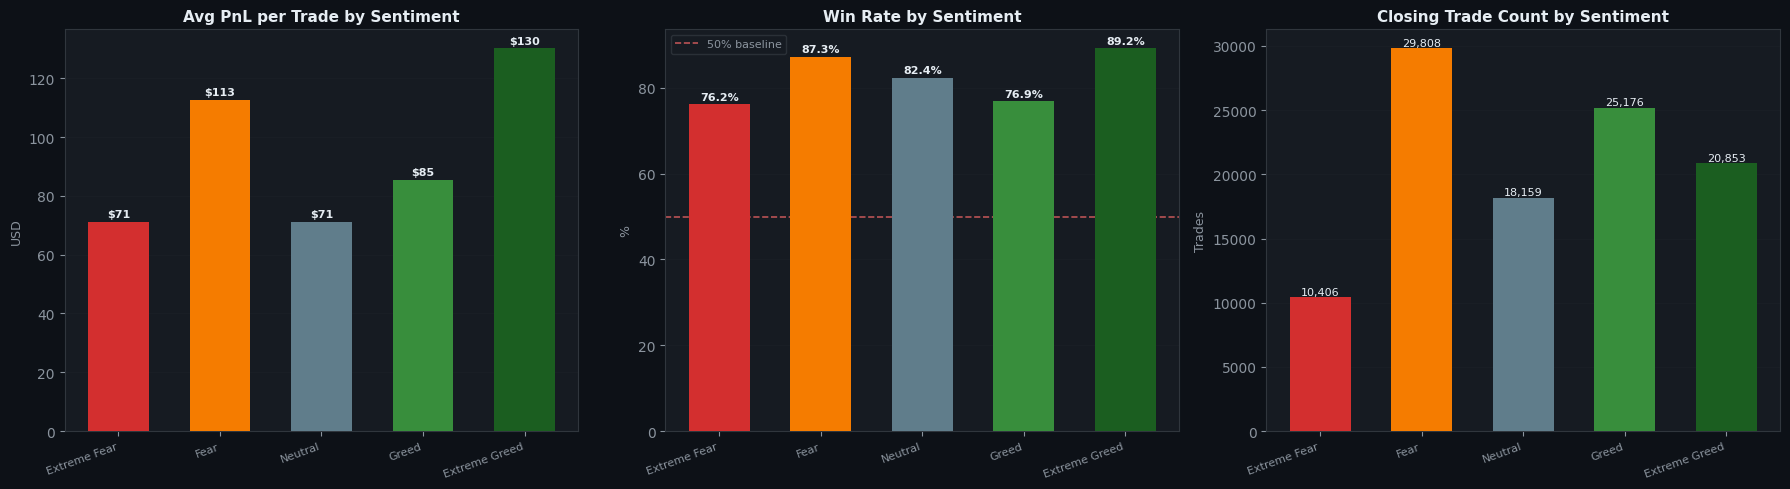

In [13]:
# Visualise — Charts 1, 2, 3
colors = [SENTIMENT_COLORS[s] for s in SENTIMENT_ORDER]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor(BG)

def style_ax(ax, title, ylabel=''):
    ax.set_facecolor(CARD_BG)
    for sp in ax.spines.values(): sp.set_edgecolor('#30363d')
    ax.set_title(title, color=TEXT, fontsize=11, fontweight='bold')
    if ylabel: ax.set_ylabel(ylabel, color=MUTED, fontsize=9)
    ax.yaxis.grid(True, alpha=0.3); ax.set_axisbelow(True)

# Avg PnL
bars = axes[0].bar(SENTIMENT_ORDER, stats['avg_pnl'], color=colors, width=0.6, zorder=3)
for b, v in zip(bars, stats['avg_pnl']):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+1, f'${v:.0f}',
                ha='center', va='bottom', color=TEXT, fontsize=8, fontweight='bold')
style_ax(axes[0], 'Avg PnL per Trade by Sentiment', 'USD')
axes[0].set_xticklabels(SENTIMENT_ORDER, rotation=20, ha='right', fontsize=8)

# Win rate
bars = axes[1].bar(SENTIMENT_ORDER, stats['win_rate']*100, color=colors, width=0.6, zorder=3)
axes[1].axhline(50, color='#ff6b6b', linestyle='--', lw=1.2, alpha=0.7, label='50% baseline')
for b, v in zip(bars, stats['win_rate']*100):
    axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+0.5, f'{v:.1f}%',
                ha='center', va='bottom', color=TEXT, fontsize=8, fontweight='bold')
style_ax(axes[1], 'Win Rate by Sentiment', '%')
axes[1].set_xticklabels(SENTIMENT_ORDER, rotation=20, ha='right', fontsize=8)
axes[1].legend(facecolor=CARD_BG, edgecolor='#30363d', labelcolor=MUTED, fontsize=8)

# Trade count
bars = axes[2].bar(SENTIMENT_ORDER, stats['trade_count'], color=colors, width=0.6, zorder=3)
for b, v in zip(bars, stats['trade_count']):
    axes[2].text(b.get_x()+b.get_width()/2, b.get_height()+50, f'{int(v):,}',
                ha='center', va='bottom', color=TEXT, fontsize=8)
style_ax(axes[2], 'Closing Trade Count by Sentiment', 'Trades')
axes[2].set_xticklabels(SENTIMENT_ORDER, rotation=20, ha='right', fontsize=8)

plt.tight_layout()
plt.savefig('chart1_sentiment_overview.png', dpi=130, bbox_inches='tight', facecolor=BG)
plt.show()


## 4. Monthly PnL vs Fear & Greed Index

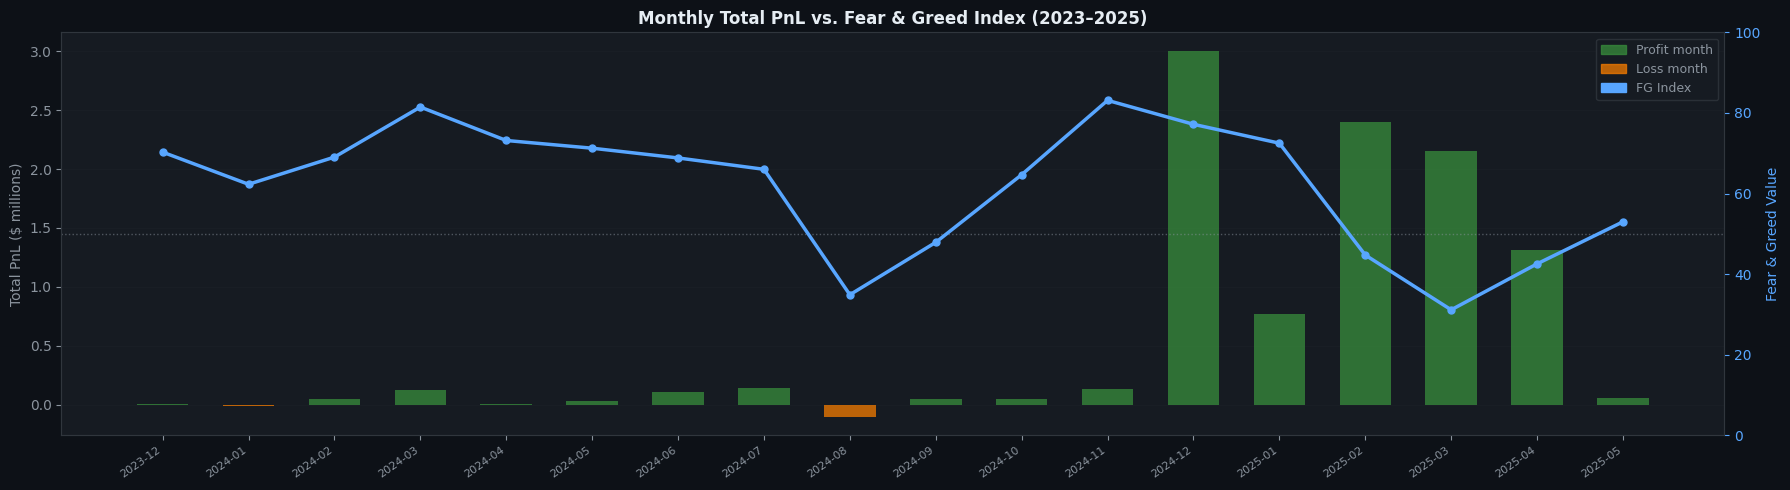

In [14]:
# Monthly aggregation
monthly_pnl = closes.groupby('month')['Closed PnL'].sum()
monthly_fg_tmp = merged.copy()
monthly_fg_tmp['month'] = pd.to_datetime(monthly_fg_tmp['date']).dt.to_period('M')
monthly_fg_agg = monthly_fg_tmp.groupby('month')['value'].mean()
common = monthly_pnl.index.intersection(monthly_fg_agg.index)
monthly_pnl = monthly_pnl.loc[common]
monthly_fg_agg = monthly_fg_agg.loc[common]
month_labels = [str(m) for m in common]

fig, ax = plt.subplots(figsize=(18, 5))
ax2 = ax.twinx()
fig.patch.set_facecolor(BG)

x = np.arange(len(month_labels))
pnl_vals = monthly_pnl.values / 1e6
bar_colors = [SENTIMENT_COLORS['Greed'] if v >= 0 else SENTIMENT_COLORS['Fear'] for v in pnl_vals]

ax.bar(x, pnl_vals, color=bar_colors, alpha=0.75, width=0.6, zorder=3)
ax2.plot(x, monthly_fg_agg.values, color=ACCENT, lw=2.5, marker='o', markersize=5, zorder=4)
ax2.axhline(50, color=MUTED, linestyle=':', lw=1, alpha=0.5)

for sp in ax.spines.values(): sp.set_edgecolor('#30363d')
ax.set_facecolor(CARD_BG)
ax.set_title('Monthly Total PnL vs. Fear & Greed Index (2023–2025)',
             color=TEXT, fontsize=12, fontweight='bold')
ax.set_ylabel('Total PnL ($ millions)', color=MUTED)
ax2.set_ylabel('Fear & Greed Value', color=ACCENT)
ax.set_xticks(x)
ax.set_xticklabels(month_labels, rotation=35, ha='right', fontsize=8)
ax.yaxis.grid(True, alpha=0.3); ax.set_axisbelow(True)
ax2.set_ylim(0, 100)
ax2.tick_params(colors=ACCENT)

handles = [mpatches.Patch(color=SENTIMENT_COLORS['Greed'], alpha=0.75, label='Profit month'),
           mpatches.Patch(color=SENTIMENT_COLORS['Fear'], alpha=0.75, label='Loss month'),
           mpatches.Patch(color=ACCENT, label='FG Index')]
ax.legend(handles=handles, facecolor=CARD_BG, edgecolor='#30363d', labelcolor=MUTED, fontsize=9)
plt.tight_layout()
plt.savefig('chart2_monthly_pnl_fg.png', dpi=130, bbox_inches='tight', facecolor=BG)
plt.show()


## 5. Long vs Short Performance by Sentiment

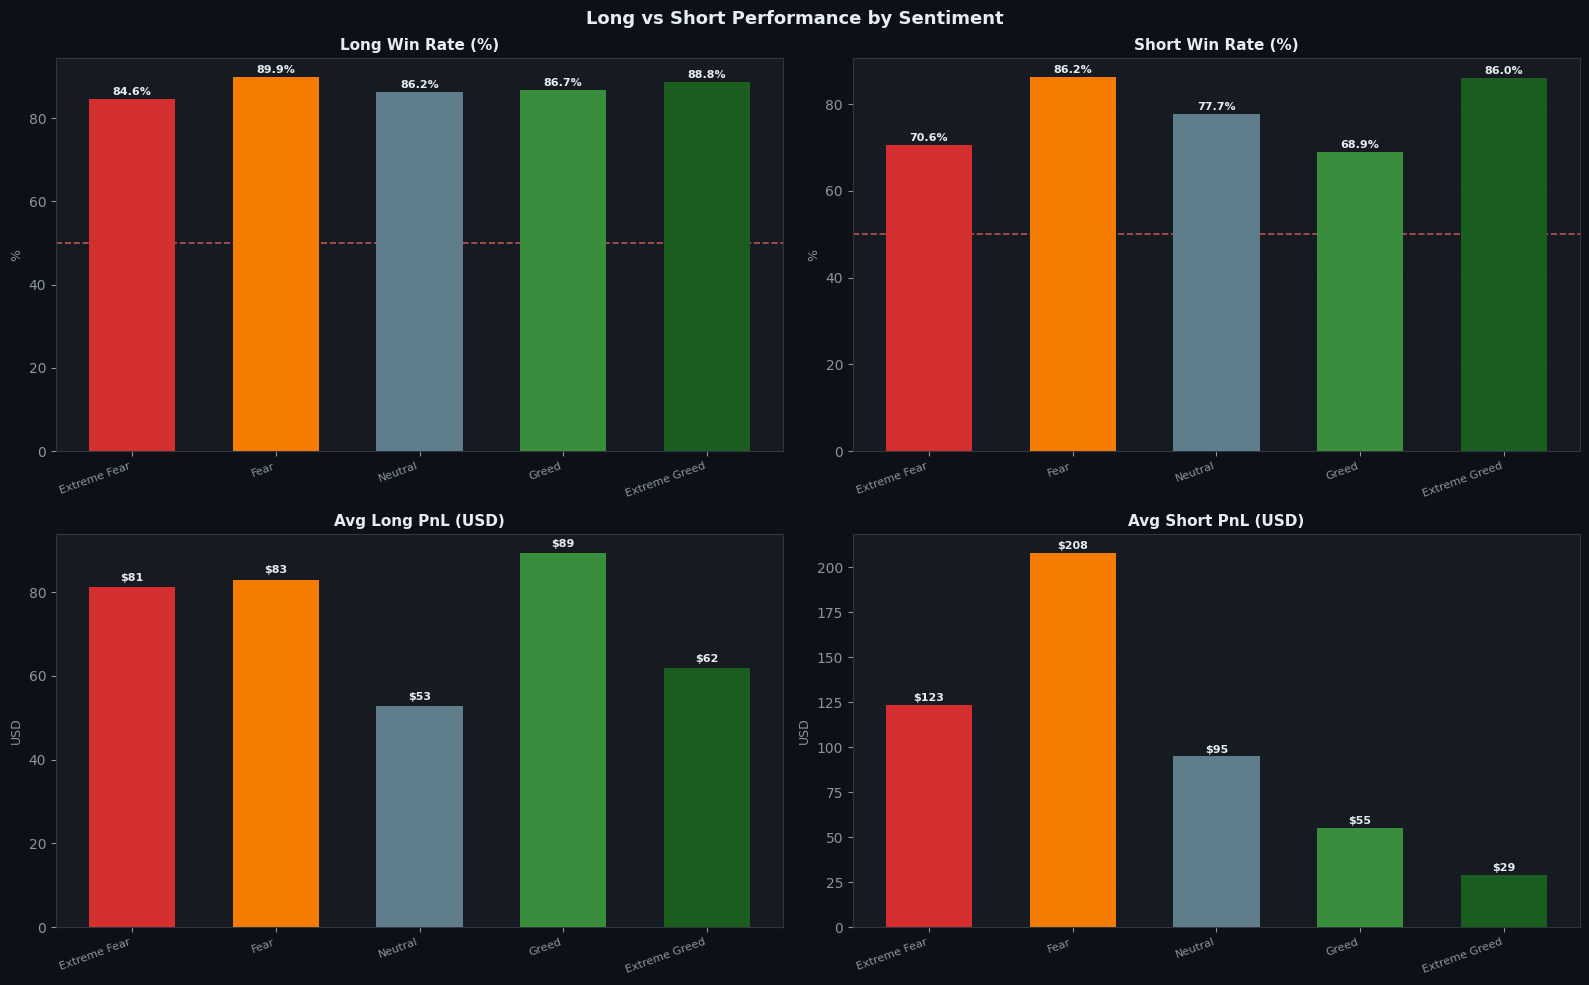

In [15]:
long_trades  = closes[closes['Direction'] == 'Close Long']
short_trades = closes[closes['Direction'] == 'Close Short']

long_wr  = long_trades.groupby('classification')['win'].mean().reindex(SENTIMENT_ORDER) * 100
short_wr = short_trades.groupby('classification')['win'].mean().reindex(SENTIMENT_ORDER) * 100
long_pnl  = long_trades.groupby('classification')['Closed PnL'].mean().reindex(SENTIMENT_ORDER)
short_pnl = short_trades.groupby('classification')['Closed PnL'].mean().reindex(SENTIMENT_ORDER)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.patch.set_facecolor(BG)
fig.suptitle('Long vs Short Performance by Sentiment', color=TEXT, fontsize=13, fontweight='bold')

for ax, data, title, ylabel in [
    (axes[0,0], long_wr,  'Long Win Rate (%)', '%'),
    (axes[0,1], short_wr, 'Short Win Rate (%)', '%'),
    (axes[1,0], long_pnl, 'Avg Long PnL (USD)', 'USD'),
    (axes[1,1], short_pnl,'Avg Short PnL (USD)', 'USD'),
]:
    bars = ax.bar(SENTIMENT_ORDER, data, color=colors, width=0.6, zorder=3)
    if 'Rate' in title:
        ax.axhline(50, color='#ff6b6b', linestyle='--', lw=1.2, alpha=0.7)
    for b, v in zip(bars, data):
        lbl = f'{v:.1f}%' if 'Rate' in title else f'${v:.0f}'
        ypos = b.get_height() + (0.5 if 'Rate' in title else 1)
        ax.text(b.get_x()+b.get_width()/2, ypos, lbl,
                ha='center', va='bottom', color=TEXT, fontsize=8, fontweight='bold')
    style_ax(ax, title, ylabel)
    ax.set_xticklabels(SENTIMENT_ORDER, rotation=20, ha='right', fontsize=8)

plt.tight_layout()
plt.savefig('chart3_long_short.png', dpi=130, bbox_inches='tight', facecolor=BG)
plt.show()


## 6. PnL Distribution & Position Sizing

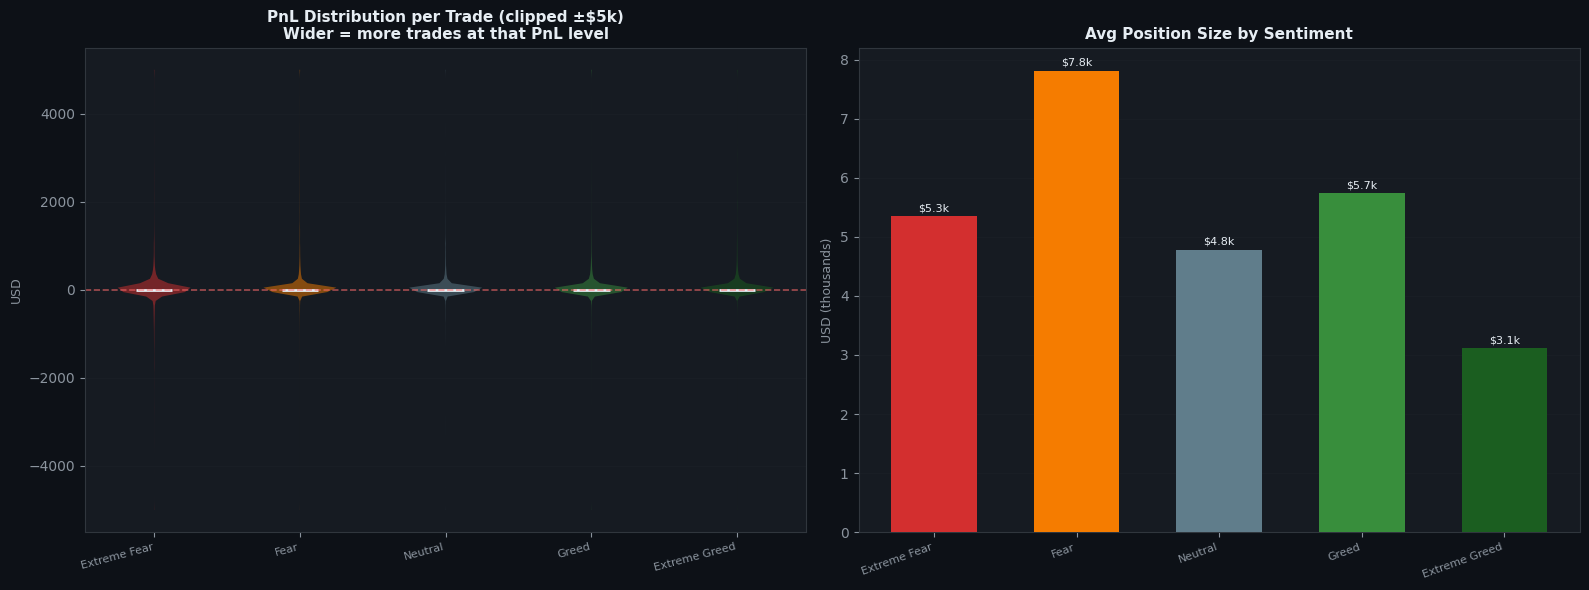

In [16]:
fig, (ax_v, ax_s) = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(BG)

# Violin — PnL distribution
plot_data = [closes[closes['classification']==s]['Closed PnL'].clip(-5000,5000).values
             for s in SENTIMENT_ORDER]
vp = ax_v.violinplot(plot_data, positions=range(len(SENTIMENT_ORDER)), showmedians=True, showextrema=False)
for pc, col in zip(vp['bodies'], colors):
    pc.set_facecolor(col); pc.set_alpha(0.5)
vp['cmedians'].set_color(TEXT); vp['cmedians'].set_linewidth(2)
ax_v.axhline(0, color='#ff6b6b', linestyle='--', lw=1.2, alpha=0.6)
style_ax(ax_v, 'PnL Distribution per Trade (clipped ±$5k)\nWider = more trades at that PnL level', 'USD')
ax_v.set_xticks(range(len(SENTIMENT_ORDER)))
ax_v.set_xticklabels(SENTIMENT_ORDER, rotation=15, ha='right', fontsize=8)

# Average position size
bars = ax_s.bar(SENTIMENT_ORDER, stats['avg_size']/1000, color=colors, width=0.6, zorder=3)
for b, v in zip(bars, stats['avg_size']/1000):
    ax_s.text(b.get_x()+b.get_width()/2, b.get_height()+0.05, f'${v:.1f}k',
             ha='center', va='bottom', color=TEXT, fontsize=8)
style_ax(ax_s, 'Avg Position Size by Sentiment', 'USD (thousands)')
ax_s.set_xticklabels(SENTIMENT_ORDER, rotation=20, ha='right', fontsize=8)

plt.tight_layout()
plt.savefig('chart4_distribution_sizing.png', dpi=130, bbox_inches='tight', facecolor=BG)
plt.show()


## 7. Notable Trades & Anomalies

In [17]:
print("=== TOP 5 BIGGEST WINS ===")
print(closes.nlargest(5, 'Closed PnL')[
    ['date','Coin','Closed PnL','classification','Direction','Size USD']
].to_string(index=False))

print()
print("=== TOP 5 BIGGEST LOSSES ===")
print(closes.nsmallest(5, 'Closed PnL')[
    ['date','Coin','Closed PnL','classification','Direction','Size USD']
].to_string(index=False))


=== TOP 5 BIGGEST WINS ===
      date Coin   Closed PnL classification   Direction  Size USD
2025-04-12  ETH 135329.09010           Fear Close Short 292870.12
2025-02-28  ETH 115287.00000   Extreme Fear Close Short 685200.00
2025-04-12  ETH  78682.72032           Fear Close Short 170279.86
2025-01-08  ETH  74530.52371          Greed Close Short 921670.14
2025-04-12  ETH  72377.74821           Fear Close Short 156635.06

=== TOP 5 BIGGEST LOSSES ===
      date  Coin    Closed PnL classification   Direction  Size USD
2024-12-06   ETH -117990.10410          Greed Close Short 814524.17
2025-04-23 TRUMP  -83056.32000          Greed Close Short 214400.00
2025-04-23 TRUMP  -41910.06915          Greed Close Short 115769.55
2025-04-18   SOL  -35681.74723           Fear Close Short 237538.13
2025-04-23 TRUMP  -34338.53409          Greed Close Short  95737.60


## 8. Key Insights & Trading Strategy Recommendations

### 📊 Summary of Findings

| Sentiment | Avg PnL/Trade | Win Rate | Avg Position Size | Key Pattern |
|-----------|--------------|----------|-------------------|-------------|
| Extreme Fear | $71 | 76.2% | $5,350 | Smaller but safer; shorts dominate |
| Fear | $113 | 87.3% | $7,816 | Highest position sizes; shorts very profitable |
| Neutral | $71 | 82.4% | $4,783 | Most conservative; baseline performance |
| Greed | $85 | 76.9% | $5,737 | Riskier; short squeezes cause big losses |
| Extreme Greed | $130 | 89.2% | $3,112 | Highest avg PnL; momentum longs work well |

---

### 💡 Key Insights

**1. Extreme Greed = Best Risk-Adjusted Returns**  
Win rate of **89.2%** and avg PnL of **$130/trade** during Extreme Greed. Momentum long strategies dominate. Traders ride the bull efficiently.

**2. Fear is a Short Trader's Paradise**  
Short traders earn an avg of **$208/trade** during Fear periods — the highest of any sentiment-direction combination. The market is falling, and shorts catch the move.

**3. Greed Creates Short Squeeze Risk**  
The biggest losses (ETH: -$118k, TRUMP: -$83k) all occurred during **Greed** phases on **short positions**. Countertrend shorts get squeezed hard when sentiment is euphoric.

**4. Position Sizing Inversely Correlates with Sentiment Extremes**  
Traders bet bigger during Fear ($7,816 avg) and smaller during Extreme Greed ($3,112 avg) — possibly de-risking after large gains, or cautiously scaling into fear dips.

**5. December 2024 Was the Monster Month**  
$3M total PnL in Dec 2024 — driven by Greed-phase conditions and HYPE token dominance (most-traded coin). The FG index peaked alongside.

**6. HYPE Token Dominates Volume**  
With 68,005 trades (32% of all), HYPE is the primary vehicle. Any sentiment-based strategy should factor HYPE's unique volatility profile.

---

### 🎯 Strategy Recommendations

1. **Greed → Go long momentum on high-cap assets (BTC, ETH, HYPE)**. Win rates are highest. Avoid countertrend shorts.
2. **Fear → Short selectively with tight risk management**. Avg short PnL is highest here, but volatility is severe.
3. **Extreme Greed → Reduce position sizes, take profits**. Historical data shows traders naturally do this; it's the right call.
4. **Extreme Fear → Watch for reversal signals before entering longs**. Low position sizing suggests caution; use it.
5. **Avoid large short positions during Greed** — the risk of squeeze is substantial (largest single losses occur here).


In [18]:
print("Analysis complete ✅")
print(f"Total trades analysed: {len(closes):,}")
print(f"Date range: {closes['date'].min()} to {closes['date'].max()}")
print(f"Total PnL across all trades: ${closes['Closed PnL'].sum():,.0f}")
print(f"Overall win rate: {closes['win'].mean():.1%}")


Analysis complete ✅
Total trades analysed: 104,402
Date range: 2023-12-14 to 2025-05-01
Total PnL across all trades: $10,254,487
Overall win rate: 83.2%
